In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
import cmocean as cmo
import xesmf as xe
import matplotlib
from xgcm import Grid

In [4]:
# parameters for setting circular cutoff for Southern Ocean plots
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

## Drake Passage transport - requires more data

In [50]:
ds = xr.open_dataset('data_i000_glob/UvelMass_bgoseI000_SO_2013to2025_monthly.nc')

(270.0, 320.0)

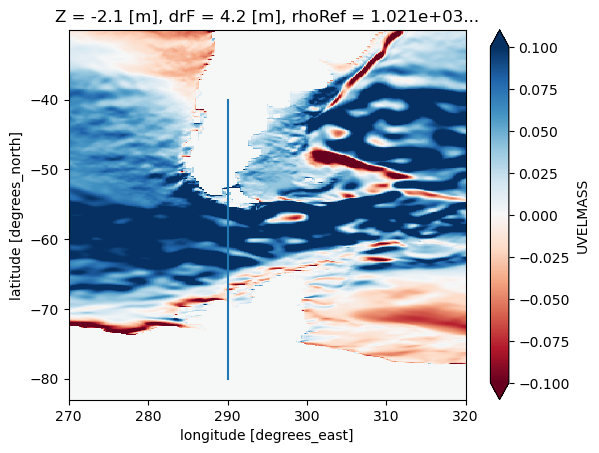

In [54]:
ds.UVELMASS[:,0,:,:].mean(dim='time').plot(cmap='RdBu', vmin=-.1, vmax=.1)
plt.plot([360-70, 360-70], [-80, -40])
plt.xlim([270, 320])

In [61]:
ds

<xarray.Dataset>
Dimensions:   (time: 112, Z: 52, YC: 614, XG: 2160)
Coordinates: (12/15)
  * XG        (XG) float32 5.551e-17 0.1667 0.3333 0.5 ... 359.5 359.7 359.8
  * YC        (YC) float32 -82.97 -82.91 -82.84 -82.78 ... -30.39 -30.25 -30.11
  * Z         (Z) float32 -2.1 -6.7 -12.15 -18.55 ... -5e+03 -5.4e+03 -5.8e+03
    drF       (Z) float32 ...
    dxC       (YC, XG) float32 ...
    dyG       (YC, XG) float32 ...
    ...        ...
    maskW     (Z, YC, XG) bool ...
    rAw       (YC, XG) float32 ...
    rLowW     (YC, XG) float32 ...
    rSurfW    (YC, XG) float32 ...
    rhoRef    (Z) float32 ...
  * time      (time) datetime64[ns] 2013-02-01 2013-03-01 ... 2022-05-01
Data variables:
    UVELMASS  (time, Z, YC, XG) float32 ...
Attributes:
    history:  Thu Jun 18 09:36:33 2026: ncks -d YC,-90.,-30. UvelMass_bgoseI0...
    NCO:      netCDF Operators version 5.3.3 (Homepage = http://nco.sf.net, C...

In [66]:
Drake_transport = (ds.UVELMASS * ds.dyG * ds.drF).sel(XG=360-70, method='nearest').sel(YC=slice(-80,-50))

<xarray.DataArray (time: 112, Z: 52, YC: 408)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)
Coordinates: (12/15)
    XG       float32 290.0
  * YC       (YC) float32 -79.97 -79.91 -79.84 -79.78 ... -50.23 -50.12 -50.01
  * Z        (Z) float32 -2.1 -6.7 -12.15 -18.55 ... -5e+03 -5.4e+03 -5.8e+03
    drF      (Z) float32 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0 400.0
    dxC      (YC) float32 3.228e+03 3.247e+03 3.267e+03 ... 1.188e+04 1.191e+04
    dyG      (YC) float32 6.949e+03 6.949e+03 6.949e+03 ... 1.188e+04 1.191e+04
    ...       ...
    maskW    (Z, YC) bool ...
    rAw      (YC) float32 2.243e+07 2.257e+07 2.27e+07 ... 1.411e+08 1.418e+08
    rLowW    (YC) float32 -1.088e+03 -1.08e+03 -1.048e+03 ... 0.0 0.0 0.0
    rSurfW   (YC) float32 -883.9 -881.8 -877.6 -871.7 -865.2 ... 0.0 0.0 0.0 0.0
    rhoRef   (Z) float32 1.021e+03 1.021e+03 1.021e+03 ... 1.043e+03 1.045e+03
  * time     (time) datetime64[ns] 2013-02-01 2013-03-01 ... 2022-05-01

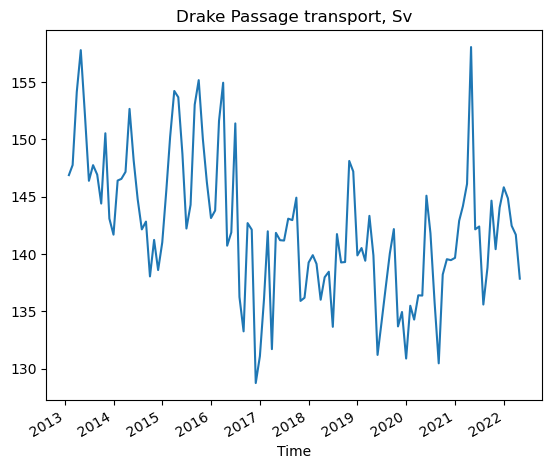

In [70]:
(1e-6*Drake_transport.sum(dim=['YC', 'Z'])).plot()
plt.title('Drake Passage transport, Sv')
plt.savefig('figures/BGOSE_i000_DrakePassage.png', format='png', dpi=150)

## Sea Ice seasonal cycle

In [73]:
ds = xr.open_dataset('data_i000_glob/SeaIceArea_bgoseI000_2013to2025_monthly.nc', use_cftime=True)

In [90]:
SIE = (ds.SIarea.where(ds.SIarea >= .15, np.nan) * ds.rA).sel(YC=slice(-90,0)).sum(dim=['XC', 'YC']).compute()

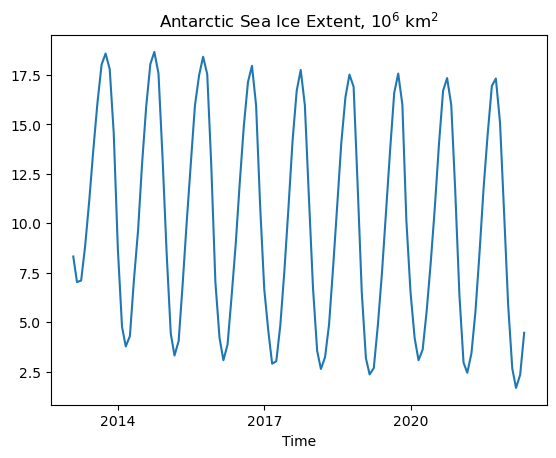

In [94]:
(1e-12 * SIE).plot()
plt.title('Antarctic Sea Ice Extent, 10$^6$ km$^2$')
plt.savefig('figures/climatology/BGOSE_i000_SHsie.png', format='png', dpi=150)

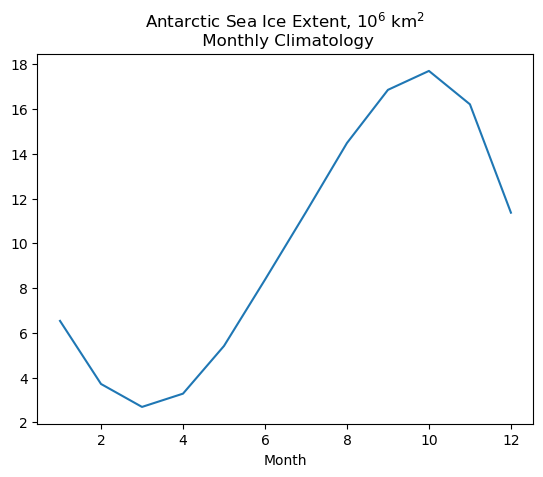

In [97]:
(1e-12*SIE[24:]).groupby(SIE[24:].time.dt.month).mean().plot()
plt.title('Antarctic Sea Ice Extent, 10$^6$ km$^2$ \n Monthly Climatology')
plt.xlabel('Month')
plt.savefig('figures/climatology/BGOSE_i000_SHsie_clim.png', format='png', dpi=150)

## Surface velocities

In [14]:
ds = xr.open_dataset('data_i000_glob/Uvel_bgoseI000_2013to2025_monthly.nc', use_cftime=True)

In [6]:
ssu = ds.UVEL[:,0,:,:].load()
ssv = ds.VVEL[:,0,:,:].load()

In [28]:
ds

<xarray.Dataset>
Dimensions:  (time: 109, YC: 285, XG: 2160, Z: 52, XC: 2160, YG: 286, Zl: 52)
Coordinates: (12/31)
    iter     (time) int64 dask.array<chunksize=(109,), meta=np.ndarray>
  * time     (time) object 2013-02-01 00:00:00 ... 2022-02-01 00:00:00
  * YC       (YC) float32 -82.97 -82.91 -82.84 -82.78 ... -65.19 -65.12 -65.05
  * XG       (XG) float32 5.551e-17 0.1667 0.3333 0.5 ... 359.5 359.7 359.8
  * Z        (Z) float32 -2.1 -6.7 -12.15 -18.55 ... -5e+03 -5.4e+03 -5.8e+03
    dyG      (YC, XG) float32 dask.array<chunksize=(285, 2160), meta=np.ndarray>
    ...       ...
  * Zl       (Zl) float32 0.0 -4.2 -9.2 -15.1 ... -4.8e+03 -5.2e+03 -5.6e+03
    rA       (YC, XC) float32 dask.array<chunksize=(285, 2160), meta=np.ndarray>
    Depth    (YC, XC) float32 dask.array<chunksize=(285, 2160), meta=np.ndarray>
    rSurfC   (YC, XC) float32 dask.array<chunksize=(285, 2160), meta=np.ndarray>
    rLowC    (YC, XC) float32 dask.array<chunksize=(285, 2160), meta=np.ndarray>
    maskInC  (YC, XC) bool dask.array<chunksize=(285, 2160), meta=np.ndarray>
Data variables:
    UVEL     (time, Z, YC, XG) float32 dask.array<chunksize=(109, 52, 285, 2160), meta=np.ndarray>
    VVEL     (time, Z, YG, XC) float32 dask.array<chunksize=(109, 52, 286, 2160), meta=np.ndarray>
    WVEL     (time, Zl, YC, XC) float32 dask.array<chunksize=(109, 52, 285, 2160), meta=np.ndarray>

In [32]:
grid = Grid(ds, periodic=['X'])
grid

<xgcm.Grid>
Y Axis (not periodic, boundary=None):
  * center   YC --> outer
  * outer    YG --> center
Z Axis (not periodic, boundary=None):
  * center   Z --> left
  * left     Zl --> center
T Axis (not periodic, boundary=None):
  * center   time
X Axis (periodic, boundary=None):
  * center   XC --> left
  * left     XG --> center

In [44]:
ssu2 = grid.interp(ssu, axis='X', to='center')
ssv2 = grid.interp(ssv, axis='Y', to='center')

In [45]:
speed = (ssu2**2 + ssv2**2)**0.5

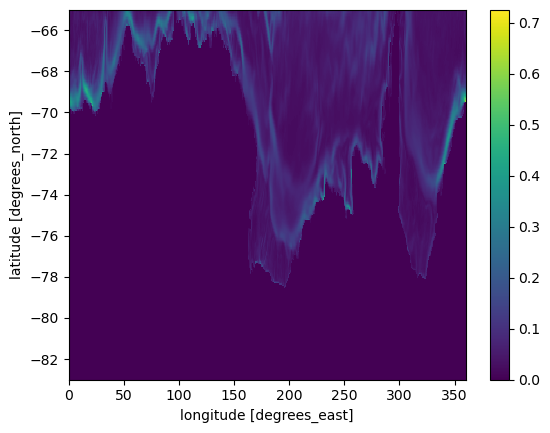

In [46]:
speed[24:,:,:].mean(dim='time').plot()

In [16]:
x = ds.UVEL.sel(XG = 360-69, method='nearest')[24:,:,:].mean(dim='time').compute()#.plot()

Text(0.5, 1.0, 'Drake Passage Zonal Velocities (m s$^{-1}$)')

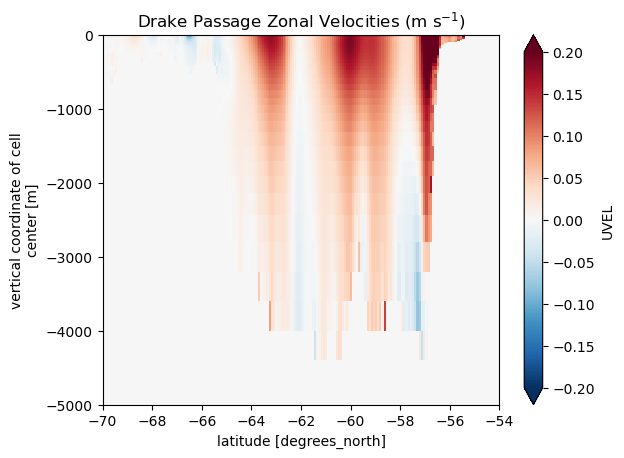

In [19]:
x.plot(vmin=-0.2, vmax=0.2, cmap='RdBu_r')
plt.xlim([-70, -54])
plt.ylim([-5000, 0])
plt.title('Drake Passage Zonal Velocities (m s$^{-1}$)')

/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

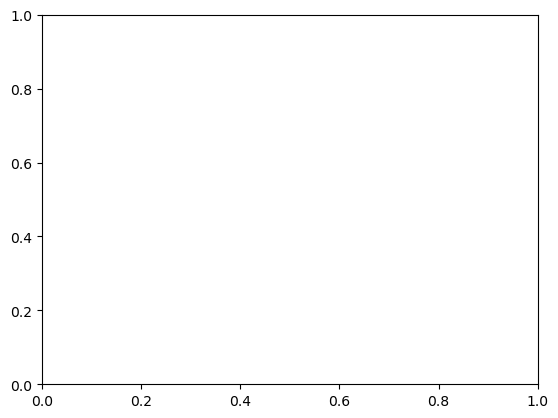

In [47]:
plt.quiver([ds.XC.data, ds.YC.data], ssu2[10,:,:], ssv2[10,:,:])

## Surface temperatures and salinities

In [98]:
ds = xr.open_dataset('data_i000_glob/Theta_bgoseI000_SO_2013to2025_monthly.nc')

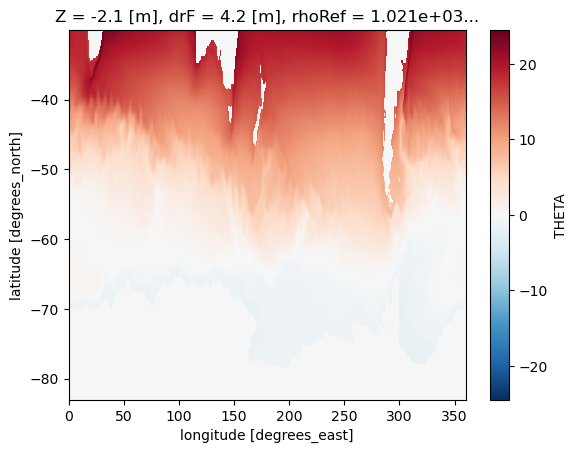

In [100]:
ds.THETA[24:,0,:,:].mean(dim='time').plot()